# Topic Modelling — Portuguese Regional News Articles

**Pipeline:**
1. **Load & Prep** — Read all `articles.jsonl` files, clean text, remove Portuguese stopwords
2. **Zero-Shot Classification** — TF-IDF + cosine similarity against predefined seed topics
3. **Topic Discovery** — BERTopic on a random sample to find blind spots
4. **Final Classification** — Merge discovered topics into master list, re-classify everything

## Step 0: Install Dependencies

In [ ]:
# %pip install polars scikit-learn nltk bertopic sentence-transformers umap-learn hdbscan matplotlib

In [84]:
topics_seed_words = {
    # Original Topics
    "Política": [
        "governo", "parlamento", "eleições", "partidos", "presidente", "primeiro-ministro", 
        "deputados", "legislação", "oposição", "ministro", "autarquias"
    ],
    "Economia": [
        "inflação", "pib", "juros", "mercado", "bolsa", "empresas", "desemprego", 
        "impostos", "salários", "orçamento", "finanças", "banca", "investimento"
    ],
    "Saúde": [
        "hospitais", "médicos", "doenças", "sns", "vacinas", "pandemia", "saúde pública", 
        "pacientes", "tratamentos", "urgências", "enfermeiros", "nutrição", "saúde mental"
    ],
    "Educação": [
        "escolas", "universidades", "professores", "alunos", "ensino", "propinas", 
        "exames", "ministério da educação", "creches", "superior"
    ],
    "Desporto": [
        "futebol", "campeonato", "seleção", "atletas", "jogos olímpicos", "treinador", 
        "modalidades", "estádio", "liga", "clubes", "medalhas"
    ],
    "Agricultura": [
        "agricultores", "colheitas", "seca", "pac", "tratores", "produção agrícola", 
        "mundo rural", "floresta", "pecuária", "rega"
    ],
    "Indústria": [
        "fábricas", "produção", "exportações", "manufatura", "setor automóvel", 
        "matérias-primas", "trabalhadores", "sindicatos", "energia"
    ],
    "Ciências": [
        "investigação", "descobertas", "espaço", "biologia", "física", "astronomia", 
        "estudos científicos", "investigadores", "laboratório"
    ],
    "Alterações climáticas": [
        "aquecimento global", "emissões de carbono", "secas", "inundações", "transição energética", 
        "clima", "cop", "gases de efeito estufa", "sustentabilidade"
    ],
    "Lifestyle": [
        "moda", "gastronomia", "viagens", "bem-estar", "decoração", "tendências", 
        "beleza", "relacionamentos"
    ],
    "Geo política": [
        "guerra", "conflitos", "diplomacia", "onu", "nato", "sanções", "fronteiras", 
        "relações internacionais", "embaixadas", "geopolítica", "tratados", "ucrânia", "rússia", "israel", "palestina", "gaza", "sudão", "afeganistão", "síria", "geopolítica"
    ],
    "Opinião": [
        "editorial", "crónica", "artigo de opinião", "análise", "comentador", 
        "perspetiva", "ponto de vista", "opinião"
    ],
    
    # Added Essential News Topics
    "Justiça e Crime": [
        "tribunal", "polícia", "investigação", "juiz", "prisão", "corrupção", 
        "sentença", "detidos", "ministério público", "crime", "homicídio", "fraude"
    ],
    "Tecnologia": [
        "inteligência artificial", "internet", "redes sociais", "software", "startups", 
        "cibersegurança", "smartphones", "inovação", "dados", "algoritmo"
    ],
    "Cultura e Entretenimento": [
        "cinema", "música", "literatura", "teatro", "concertos", "festivais", 
        "exposições", "televisão", "celebridades", "artes", "museus"
    ],
    "Sociedade": [
        "habitação", "imigração", "desigualdade", "protestos", "demografia", 
        "envelhecimento", "pobreza", "família", "manifestação", "rendas"
    ]
}

# Quick helper string to join them for TF-IDF if needed later:
# topics_strings = {topic: " ".join(words) for topic, words in topics_seed_words.items()}

## Step 1: Load & Prep Data

Load all `articles.jsonl` from `../data-scraping/data/`, keeping only articles whose domain is present in `jornais.csv`. Combine `title` + `text`, lowercase, strip Portuguese stopwords.

In [2]:
import polars as pl
from pathlib import Path
import time

DATA_DIR = Path("../data-scraping/data")
JORNAIS_CSV = Path("../data-scraping/jornais.csv")

# Load the list of known newspapers and extract their domains
jornais = pl.read_csv(JORNAIS_CSV)
known_domains = set(
    jornais["url"]
    .drop_nulls()
    .str.replace(r"^https?://", "")
    .str.replace(r"^www\.", "")
    .str.strip_chars("/")
    .to_list()
)
print(f"Known domains from jornais.csv: {len(known_domains)}")

# Scan all articles.jsonl files
t0 = time.time()
jsonl_files = sorted(DATA_DIR.glob("*/articles.jsonl"))
print(f"Found {len(jsonl_files)} articles.jsonl files")

# Force every column to Utf8 so nulls are always accepted.
ALL_UTF8 = {col: pl.Utf8 for col in [
    "id", "url", "title", "subtitle", "text", "date", "author",
    "agency", "section", "source", "timestamp", "archive_url",
    "domain", "text_hash", "fetched_at", "extractor",
]}

dfs = []
skipped = 0
for f in jsonl_files:
    try:
        df = pl.read_ndjson(f, schema_overrides=ALL_UTF8).select(
            ["id", "title", "text", "domain", "date"]
        )
        dfs.append(df)
    except Exception as e:
        skipped += 1
        print(f"  Skipping {f.parent.name}: {e}")

articles = pl.concat(dfs)
elapsed = time.time() - t0
print(f"Loaded {len(articles):,} articles in {elapsed:.1f}s (skipped {skipped} files)")
print(f"Unique domains: {articles['domain'].n_unique()}")

Known domains from jornais.csv: 713
Found 537 articles.jsonl files
Loaded 3,516,823 articles in 24.0s (skipped 0 files)
Unique domains: 540


In [3]:
# Filter to only known domains
articles = articles.filter(
    pl.col("domain")
    .str.replace(r"^www\.", "")
    .str.strip_chars("/")
    .is_in(known_domains)
)
print(f"Articles from known jornais: {len(articles):,}")

# Combine title + text into a single field, drop near-empty articles
articles = articles.with_columns(
    (pl.col("title").fill_null("") + " " + pl.col("text").fill_null(""))
    .str.strip_chars()
    .alias("full_text")
).filter(pl.col("full_text").str.len_chars() > 50)

print(f"Articles after filtering empty text: {len(articles):,}")
articles.head(3)

Articles from known jornais: 3,475,862
Articles after filtering empty text: 3,475,862


id,title,text,domain,date,full_text
str,str,str,str,str,str
"""88caa7c06701d4aababb797ffede50…","""21TV e SAPO.PT: Juntas pela In…","""A 21TV, uma WEBTV da região Oe…","""21tv.sapo.pt/homepage""","""2023-07-30""","""21TV e SAPO.PT: Juntas pela In…"
"""9136a340d4cf545335eaf43db36e11…","""Incidência semanal de fiscaliz…","""O Comando Metropolitano de Lis…","""21tv.sapo.pt/homepage""","""2024-01-07""","""Incidência semanal de fiscaliz…"
"""9dfda7664d7ee9eb4cf8326fdddabb…","""Violência doméstica com recurs…","""A Polícia Judiciária, através …","""21tv.sapo.pt/homepage""","""2024-01-07""","""Violência doméstica com recurs…"


In [4]:
import gc, os, ctypes

# Delete loading intermediates
for _v in ['dfs', 'known_domains', 'jsonl_files', 'ALL_UTF8', 'jornais', 'df']:
    if _v in dir():
        exec(f"del {_v}")
gc.collect()

# Force glibc to release free memory back to OS
try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
    print("malloc_trim: released fragmented memory to OS")
except Exception:
    pass

# Show actual process RSS
rss_mb = os.popen("ps -o rss= -p %d" % os.getpid()).read().strip()
print(f"Kernel RSS: {int(rss_mb)/1024:.0f} MB")

malloc_trim: released fragmented memory to OS
Kernel RSS: 17470 MB


In [5]:
# Drop original text columns — full_text already has title+text combined
# Rechunk forces a single contiguous allocation, freeing fragmented old chunks
if "text" in articles.columns:
    articles = articles.drop(["text", "title"]).rechunk()
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

rss_mb = os.popen("ps -o rss= -p %d" % os.getpid()).read().strip()
print(f"articles: {articles.estimated_size('mb'):.0f} MB ({len(articles.columns)} cols: {articles.columns})")
print(f"Kernel RSS: {int(rss_mb)/1024:.0f} MB")

articles: 7608 MB (4 cols: ['id', 'domain', 'date', 'full_text'])
Kernel RSS: 17696 MB


In [6]:
# Download Portuguese stopwords
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

PT_STOPWORDS = set(stopwords.words("portuguese"))
# Add common news boilerplate words
PT_STOPWORDS.update([
    "disse", "ainda", "pode", "vai", "ser", "ter", "cada", "onde", "quando",
    "porque", "além", "então", "assim", "aqui", "foto", "leia", "veja",
    "notícia", "jornal", "artigo", "publicado", "partilhar", "comentários",
])
print(f"Portuguese stopwords: {len(PT_STOPWORDS)}")

Portuguese stopwords: 228


## Step 2: Zero-Shot Classification (TF-IDF + Cosine Similarity)

Convert both the seed topic phrases and all article texts into TF-IDF vectors, then assign each article the topic with highest cosine similarity. This is pure sparse matrix math — no GPU needed.

**Improvement over the plan:** We use `sublinear_tf=True` (log-scaled TF) and bigrams to capture multi-word seed phrases like "inteligência artificial" or "saúde pública".

In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Build topic "documents" from seed words — each topic becomes a pseudo-document
topic_names = list(topics_seed_words.keys())
topic_docs = [" ".join(words) for words in topics_seed_words.values()]

print(f"Topics: {len(topic_names)}")
for name, doc in zip(topic_names, topic_docs):
    print(f"  {name}: {doc[:80]}...")

Topics: 16
  Política: governo parlamento eleições partidos presidente primeiro-ministro deputados legi...
  Economia: inflação pib juros mercado bolsa empresas desemprego impostos salários orçamento...
  Saúde: hospitais médicos doenças sns vacinas pandemia saúde pública pacientes tratament...
  Educação: escolas universidades professores alunos ensino propinas exames ministério da ed...
  Desporto: futebol campeonato seleção atletas jogos olímpicos treinador modalidades estádio...
  Agricultura: agricultores colheitas seca pac tratores produção agrícola mundo rural floresta ...
  Indústria: fábricas produção exportações manufatura setor automóvel matérias-primas trabalh...
  Ciências: investigação descobertas espaço biologia física astronomia estudos científicos i...
  Alterações climáticas: aquecimento global emissões de carbono secas inundações transição energética cli...
  Lifestyle: moda gastronomia viagens bem-estar decoração tendências beleza relacionamentos...
  Geo política: 

### NOTE IF new articles are added
TFIDF_ARTICLES_PATH needs to be re-generated with the new articles, but the same vectorizer can be re-used for consistency. The topic assignment code can then be re-run on the new TF-IDF matrix.

In [ ]:
import joblib
from scipy.sparse import save_npz, load_npz, vstack as sparse_vstack

VECTORIZER_PATH = MODELS_DIR / "tfidf_vectorizer.joblib"
TFIDF_ARTICLES_PATH = MODELS_DIR / "tfidf_articles.npz"

# --- Load or fit vectorizer ---
if VECTORIZER_PATH.exists():
    print("Loading cached vectorizer...")
    vectorizer = joblib.load(VECTORIZER_PATH)
    print(f"  Vectorizer: {len(vectorizer.vocabulary_):,} features")
else:
    t0 = time.time()
    VOCAB_SAMPLE = 500_000
    sample_idx = np.random.RandomState(42).choice(
        len(articles), min(VOCAB_SAMPLE, len(articles)), replace=False
    )
    sample_texts = articles[sample_idx.tolist()]["full_text"].to_list()

    vectorizer = TfidfVectorizer(
        stop_words=list(PT_STOPWORDS),
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=100_000,
        min_df=3,
        max_df=0.7,
        dtype=np.float32,
    )
    vectorizer.fit(sample_texts)
    del sample_texts, sample_idx
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

    joblib.dump(vectorizer, VECTORIZER_PATH)
    print(f"Vocabulary fitted on {VOCAB_SAMPLE:,} docs: {len(vectorizer.vocabulary_):,} features")
    print(f"Saved vectorizer → {VECTORIZER_PATH}")

# --- Load or build article TF-IDF matrix ---
# Rebuild if missing OR if article count changed (new articles added)
need_rebuild = not TFIDF_ARTICLES_PATH.exists()
if not need_rebuild:
    tfidf_articles = load_npz(TFIDF_ARTICLES_PATH)
    if tfidf_articles.shape[0] != len(articles):
        print(f"Article count changed ({tfidf_articles.shape[0]:,} cached vs {len(articles):,} current) — rebuilding matrix...")
        del tfidf_articles
        need_rebuild = True
    else:
        print(f"Loaded cached article matrix: {tfidf_articles.shape} ({tfidf_articles.nnz:,} non-zero)")

if need_rebuild:
    t0 = time.time()
    TRANSFORM_BATCH = 200_000
    chunks = []
    for start in range(0, len(articles), TRANSFORM_BATCH):
        end = min(start + TRANSFORM_BATCH, len(articles))
        batch_texts = articles[start:end]["full_text"].to_list()
        chunks.append(vectorizer.transform(batch_texts))
        del batch_texts
        gc.collect()
        print(f"  Transformed {start:,}–{end:,}")

    tfidf_articles = sparse_vstack(chunks, format="csr")
    del chunks
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

    save_npz(TFIDF_ARTICLES_PATH, tfidf_articles)
    print(f"Built & saved article matrix in {time.time() - t0:.1f}s → {TFIDF_ARTICLES_PATH}")

tfidf_topics = vectorizer.transform(topic_docs)
print(f"Article matrix: {tfidf_articles.shape} ({tfidf_articles.nnz:,} non-zero entries)")
print(f"Topic matrix: {tfidf_topics.shape}")

Loading cached TF-IDF vectorizer and article matrix...
  Vectorizer: 100,000 features
  Article matrix: (3475862, 100000) (609,552,407 non-zero)
Article matrix: (3475862, 100000) (609,552,407 non-zero entries)
Topic matrix: (16, 100000)


In [10]:
# import joblib
# from scipy.sparse import save_npz, load_npz, vstack as sparse_vstack

# VECTORIZER_PATH = MODELS_DIR / "tfidf_vectorizer.joblib"
# TFIDF_ARTICLES_PATH = MODELS_DIR / "tfidf_articles.npz"
# # Save to disk
# joblib.dump(vectorizer, VECTORIZER_PATH)
# save_npz(TFIDF_ARTICLES_PATH, tfidf_articles)
# print(f"Saved vectorizer → {VECTORIZER_PATH}")
# print(f"Saved tfidf_articles → {TFIDF_ARTICLES_PATH}")

Saved vectorizer → models/tfidf_vectorizer.joblib
Saved tfidf_articles → models/tfidf_articles.npz


In [11]:
# Compute cosine similarity: articles × topics → (n_articles, n_topics)
# Process in batches to keep memory under control
t0 = time.time()

BATCH_SIZE = 100_000
n_articles = tfidf_articles.shape[0]
best_topic_idx = np.empty(n_articles, dtype=np.int32)
best_topic_score = np.empty(n_articles, dtype=np.float32)

for start in range(0, n_articles, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_articles)
    # cosine_similarity returns dense (batch_size, n_topics)
    sim = cosine_similarity(tfidf_articles[start:end], tfidf_topics)
    best_topic_idx[start:end] = sim.argmax(axis=1)
    best_topic_score[start:end] = sim.max(axis=1)
    print(f"  Batch {start:,}–{end:,} done")

elapsed = time.time() - t0
print(f"\nCosine similarity: {elapsed:.1f}s")

# Map indices to topic names
best_topic_names = [topic_names[i] for i in best_topic_idx]

# Add results to the polars DataFrame
articles = articles.with_columns([
    pl.Series("topic", best_topic_names),
    pl.Series("topic_score", best_topic_score),
])

print(f"\nScore distribution:")
print(f"  Mean: {best_topic_score.mean():.4f}")
print(f"  Median: {np.median(best_topic_score):.4f}")
print(f"  >0.05 (confident): {(best_topic_score > 0.05).sum():,} ({(best_topic_score > 0.05).mean()*100:.1f}%)")
print(f"  <0.02 (weak): {(best_topic_score < 0.02).sum():,} ({(best_topic_score < 0.02).mean()*100:.1f}%)")

  Batch 0–100,000 done
  Batch 100,000–200,000 done
  Batch 200,000–300,000 done
  Batch 300,000–400,000 done
  Batch 400,000–500,000 done
  Batch 500,000–600,000 done
  Batch 600,000–700,000 done
  Batch 700,000–800,000 done
  Batch 800,000–900,000 done
  Batch 900,000–1,000,000 done
  Batch 1,000,000–1,100,000 done
  Batch 1,100,000–1,200,000 done
  Batch 1,200,000–1,300,000 done
  Batch 1,300,000–1,400,000 done
  Batch 1,400,000–1,500,000 done
  Batch 1,500,000–1,600,000 done
  Batch 1,600,000–1,700,000 done
  Batch 1,700,000–1,800,000 done
  Batch 1,800,000–1,900,000 done
  Batch 1,900,000–2,000,000 done
  Batch 2,000,000–2,100,000 done
  Batch 2,100,000–2,200,000 done
  Batch 2,200,000–2,300,000 done
  Batch 2,300,000–2,400,000 done
  Batch 2,400,000–2,500,000 done
  Batch 2,500,000–2,600,000 done
  Batch 2,600,000–2,700,000 done
  Batch 2,700,000–2,800,000 done
  Batch 2,800,000–2,900,000 done
  Batch 2,900,000–3,000,000 done
  Batch 3,000,000–3,100,000 done
  Batch 3,100,000–3,2

In [12]:
del tfidf_topics, topic_docs
gc.collect()
print("Freed TF-IDF intermediates (kept tfidf_articles + vectorizer for re-classification)")

Freed TF-IDF intermediates (kept tfidf_articles + vectorizer for re-classification)


Topic distribution (all articles):
  Política                        867,659
  Desporto                        332,645
  Cultura e Entretenimento        283,863
  Saúde                           247,422
  Justiça e Crime                 227,925
  Educação                        217,807
  Economia                        192,640
  Opinião                         166,640
  Lifestyle                       162,824
  Tecnologia                      149,849
  Indústria                       127,753
  Ciências                        123,121
  Agricultura                     116,234
  Sociedade                       109,763
  Geo política                     75,169
  Alterações climáticas            74,548


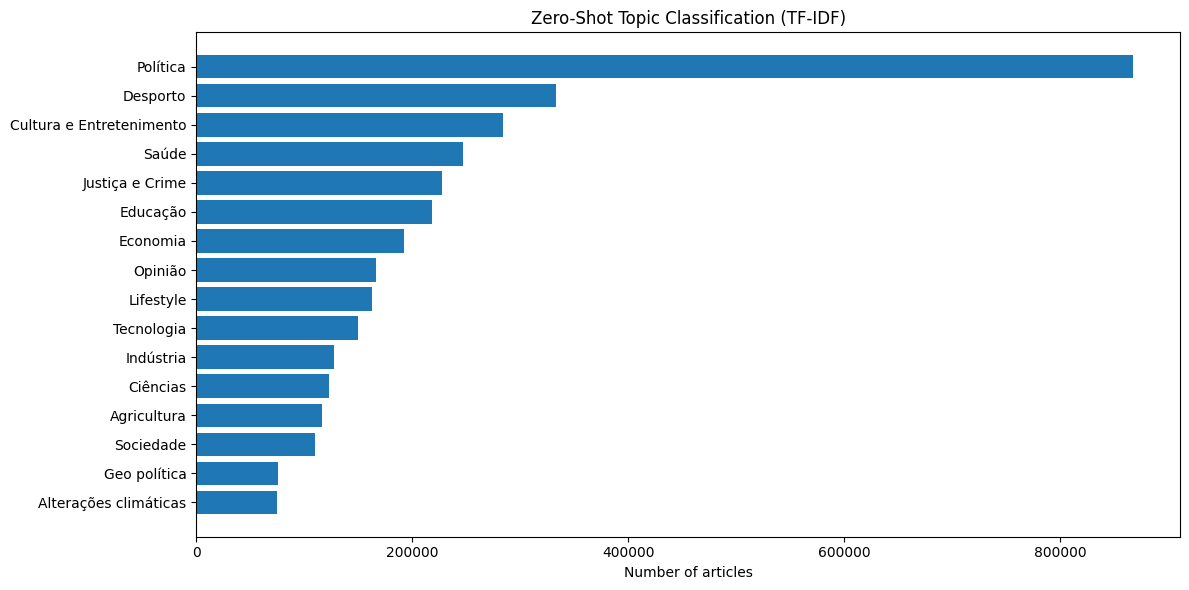

In [13]:
# Topic distribution
import matplotlib.pyplot as plt

topic_counts = articles.group_by("topic").len().sort("len", descending=True)
print("Topic distribution (all articles):")
for row in topic_counts.iter_rows():
    print(f"  {row[0]:30s} {row[1]:>8,}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    topic_counts["topic"].to_list()[::-1],
    topic_counts["len"].to_list()[::-1],
)
ax.set_xlabel("Number of articles")
ax.set_title("Zero-Shot Topic Classification (TF-IDF)")
plt.tight_layout()
plt.show()

In [14]:
# Inspect low-confidence articles — these are the ones our topics might not cover
low_conf = articles.filter(pl.col("topic_score") < 0.02)
print(f"Low-confidence articles (<0.02 score): {len(low_conf):,}")
print(f"\nSample titles from low-confidence articles:")
for row in low_conf.sample(min(20, len(low_conf)), seed=42).select("full_text", "topic", "topic_score").iter_rows():
    print(f"  [{row[1]:20s} {row[2]:.4f}] {row[0][:100]}")

Low-confidence articles (<0.02 score): 1,649,705

Sample titles from low-confidence articles:
  [Desporto             0.0081] IKEA iniciou processo de limpeza dos terrenos da futura loja de Loulé A IKEA Portugal anunciou que d
  [Sociedade            0.0174] Maria Anália Marques de Freitas Seus filhos, Gracinda Marques seu marido e filho, Judite Marques e f
  [Política             0.0000] 28/11/2019 Arquivo
Na Junta de Freguesia de Retorta , em Vila do Conde, realiza-se mais mais uma ses
  [Ciências             0.0125] Proibição de circular entre concelhos | O Atual Proibição de circular entre concelhos
A partir das 2
  [Política             0.0000] Dia do deserto diocesano Fátima: Dia do deserto diocesano
- 02/03/2023 - 9:42
No dia 18 de março, o 
  [Economia             0.0083] VINHOS: Região dos Vinhos Verdes e Instituto do Douro e Porto investem 60 mil euros em sinalização A
  [Opinião              0.0182] Como vigia a NASA um voo espacial? - Coolkids - Portal beira.pt No passado, 

## Step 3: Topic Discovery (BERTopic on Random Sample)

Sample 100k articles and run BERTopic to discover topics we may have missed.

**Improvements over the plan:**
- Use `paraphrase-multilingual-MiniLM-L12-v2` instead of `all-MiniLM-L6-v2` — it's the same speed but actually understands Portuguese (the English-only model would be nearly useless here)
- Truncate long articles to ~512 tokens before embedding to avoid wasted compute
- Use the low-confidence articles as a priority in the sample — they're the most likely to contain unknown topics

In [30]:
# Build a biased sample: prioritize low-confidence articles for discovery
SAMPLE_SIZE = 100_000

# Take all low-confidence articles + random fill from the rest
low_conf_sample = articles.filter(pl.col("topic_score") < 0.03)
remaining_needed = max(0, SAMPLE_SIZE - len(low_conf_sample))

if remaining_needed > 0:
    high_conf = articles.filter(pl.col("topic_score") >= 0.03).sample(
        n=min(remaining_needed, len(articles.filter(pl.col("topic_score") >= 0.03))),
        seed=42,
    )
    sample_df = pl.concat([low_conf_sample, high_conf])
else:
    sample_df = low_conf_sample.sample(n=SAMPLE_SIZE, seed=42)

# Truncate text to first ~500 words for faster embedding
sample_texts = (
    sample_df["full_text"]
    .str.split(" ")
    .list.head(500)
    .list.join(" ")
    .to_list()
)

print(f"Sample size: {len(sample_texts):,}")
print(f"  Low-confidence articles included: {len(low_conf_sample):,}")
print(f"  Avg text length (chars): {sum(len(t) for t in sample_texts) / len(sample_texts):.0f}")

Sample size: 100,000
  Low-confidence articles included: 2,281,102
  Avg text length (chars): 1557


In [16]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

# Multilingual model that handles Portuguese well — same speed as MiniLM-L6
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Configure sub-models for BERTopic
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,      # reduce to 5D before clustering
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)
hdbscan_model = HDBSCAN(
    min_cluster_size=150,   # minimum topic size
    min_samples=10,
    prediction_data=True,
)
# Portuguese-aware tokenizer for the topic representation
vectorizer_model = CountVectorizer(
    stop_words=list(PT_STOPWORDS),
    ngram_range=(1, 2),
    min_df=10,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True,
)

print("BERTopic configured. Ready to fit.")

2026-04-29 13:00:55.315410: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 13:00:55.364604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777464055.383023  124098 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777464055.390398  124098 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 13:00:55.418595: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

BERTopic configured. Ready to fit.


In [ ]:
# already ran: pip install 'transformers>=4.45,<5'

In [ ]:
BERTOPIC_PATH = MODELS_DIR / "bertopic_model"

if BERTOPIC_PATH.exists():
    print(f"Loading cached BERTopic model from {BERTOPIC_PATH}...")
    topic_model = BERTopic.load(BERTOPIC_PATH)
    # We still need topics for the sample — re-transform
    topics, probs = topic_model.transform(sample_texts)
    print(f"Loaded model with {len(topic_model.get_topic_info()) - 1} topics")
else:
    # Fit BERTopic — this is the slowest step (~1-2h on CPU)
    t0 = time.time()
    topics, probs = topic_model.fit_transform(sample_texts)
    elapsed = time.time() - t0
    print(f"\nBERTopic fit complete in {elapsed/60:.1f} minutes")

    # Save model to disk
    topic_model.save(BERTOPIC_PATH, serialization="safetensors", save_ctfidf=True, save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    print(f"Saved BERTopic model → {BERTOPIC_PATH}")

print(f"Discovered {len(set(topics)) - 1} topics (excluding outlier topic -1)")
print(f"Outliers: {topics.count(-1):,} / {len(topics):,} ({topics.count(-1)/len(topics)*100:.1f}%)")

In [ ]:
del sample_texts
gc.collect()
print("Freed BERTopic sample texts")

Freed BERTopic sample texts


In [53]:
import ast

# Inspect discovered topics
topic_info = topic_model.get_topic_info()
print(f"\nTop 50 discovered topics:")
for _, row in topic_info.head(51).iterrows():
    if row["Topic"] == -1:  # skip outliers
        continue

    words = row["Representation"]
    if isinstance(words, str):
        words = ast.literal_eval(words)

    # print(f'{row["Count"]:5d} "NEW_TOPIC_{int(row["Topic"])}": [{", ".join(f"""\"{w}\"""" for w in words)}],')
    print(f'"NEW_TOPIC_{int(row["Topic"])}": [{", ".join(f"""\"{w}\"""" for w in words)}],')


Top 50 discovered topics:
"NEW_TOPIC_0": ["prova", "equipa", "jogo", "clube", "campeonato", "lugar", "jornada", "pontos", "vitória", "final"],
"NEW_TOPIC_1": ["festival", "música", "dia", "concerto", "igreja", "feira", "palco", "teatro", "espetáculo", "festa"],
"NEW_TOPIC_2": ["psd", "ps", "presidente", "partido", "candidato", "eleições", "lista", "câmara", "assembleia", "votos"],
"NEW_TOPIC_3": ["trânsito", "rua", "circulação", "mobilidade", "transportes", "transporte", "estrada", "linha", "estacionamento", "via"],
"NEW_TOPIC_4": ["exposição", "arte", "museu", "fotografia", "artista", "patente", "mostra", "pintura", "artistas", "obras"],
"NEW_TOPIC_5": ["detido", "suspeito", "homem", "gnr", "psp", "furto", "judicial", "deteve", "territorial", "militares"],
"NEW_TOPIC_6": ["saúde", "hospital", "cancro", "unidade", "cuidados", "hospitalar", "doentes", "centro", "mama", "serviço"],
"NEW_TOPIC_7": ["natal", "dezembro", "pai natal", "pai", "ano", "natalícia", "dia", "comércio", "quadra", 

In [20]:
# Visualize topic keywords for the top 20 discovered topics
fig = topic_model.visualize_barchart(top_n_topics=20, n_words=8)
fig.show()

In [ ]:
# del topic_model, embedding_model, umap_model, hdbscan_model, vectorizer_model
# del topics, probs, sample_df
# gc.collect()
# print("Freed BERTopic models and embeddings")

Freed BERTopic models and embeddings


## Step 4: Refine Master Topic List & Final Classification

Review BERTopic's discovered topics, merge novel ones into the seed list, then re-run TF-IDF classification over the full dataset.

**After running BERTopic**, manually inspect the output above and add any new topics to `new_topics` below. The cell below provides a starting template — edit it based on what BERTopic actually discovers.

In [27]:
for k,v in topics_seed_words.items():
    print(f"\"{k}\": [{"', '".join(v)}]")

"Política": [governo', 'parlamento', 'eleições', 'partidos', 'presidente', 'primeiro-ministro', 'deputados', 'legislação', 'oposição', 'ministro', 'autarquias]
"Economia": [inflação', 'pib', 'juros', 'mercado', 'bolsa', 'empresas', 'desemprego', 'impostos', 'salários', 'orçamento', 'finanças', 'banca', 'investimento]
"Saúde": [hospitais', 'médicos', 'doenças', 'sns', 'vacinas', 'pandemia', 'saúde pública', 'pacientes', 'tratamentos', 'urgências', 'enfermeiros]
"Educação": [escolas', 'universidades', 'professores', 'alunos', 'ensino', 'propinas', 'exames', 'ministério da educação', 'creches', 'superior]
"Desporto": [futebol', 'campeonato', 'seleção', 'atletas', 'jogos olímpicos', 'treinador', 'modalidades', 'estádio', 'liga', 'clubes', 'medalhas]
"Agricultura": [agricultores', 'colheitas', 'seca', 'pac', 'tratores', 'produção agrícola', 'mundo rural', 'floresta', 'pecuária', 'rega]
"Indústria": [fábricas', 'produção', 'exportações', 'manufatura', 'setor automóvel', 'matérias-primas', 't

In [86]:
# ─── EDIT THIS after reviewing BERTopic output ───
# Add new topics OR extend existing ones with additional keywords.
# If a key matches an existing seed topic, the words are merged (not replaced).
new_topics = {
    "Desporto": [ "equipa", "jogo", "clube", "campeonato", "jornada", "pontos", "vitória"],
    "Cultura e Entretenimento": ["festival", "música", "dia", "concerto", "igreja", "feira", "palco", "teatro", "espetáculo", "festa"],
    "Política": ["psd", "ps", "presidente", "partido", "candidato", "eleições", "câmara", "assembleia", "votos"],
    # "NEW_TOPIC_3": ["trânsito", "rua", "circulação", "mobilidade", "transportes", "transporte", "estrada", "linha", "estacionamento", "via"],
    "Cultura e Entretenimento": ["exposição", "arte", "museu", "fotografia", "artista", "patente", "mostra", "pintura", "artistas", "obras"],
    "Justiça e Crime": ["detido", "suspeito", "homem", "gnr", "psp", "furto", "judicial", "deteve", "territorial", "militares"],
    "Saúde": ["saúde", "hospital", "cancro", "unidade", "cuidados", "hospitalar", "doentes", "centro", "mama", "serviço"],
    # "Natal": ["natal", "dezembro", "pai natal", "pai", "ano", "natalícia", "dia", "comércio", "quadra", "crianças"],
    "Incêndios": ["incêndio", "bombeiros", "fogo", "chamas", "operacionais", "incêndios", "meios", "deflagrou", "meios aéreos", "aéreos"],
    "Saúde": ["covid", "covid 19", "novos casos", "óbitos", "mortes"],
    "Turismo": ["turismo", "dormidas", "turística", "turístico", "algarve", "destino", "portugal", "região", "turísticos", "turistas"],
    "Segurança Rodoviária": ["acidente", "feridos", "colisão", "ferido", "bombeiros", "hospital", "despiste", "local", "viaturas", "ligeiros"],
    "Aviação": ["aeroporto", "voos", "aérea", "passageiros", "sata", "voo", "tap", "aeroportos", "companhia", "ryanair"],
    "Sociedade": ["água", "abastecimento", "águas", "abastecimento água", "saneamento", "águas residuais", "residuais", "rede", "rua", "rio"],
    "REMOVER_NOTICIAS_COM_TOPICO_1": ["realizações", "castelo vide", "vide", "ncvide", "email ncvide", "ncvide gmail", "nisa", "interessam sobretudo", "todos redacção", "realizações endereço"],
    "Educação": ["escola", "crianças", "escolar", "jovens", "escolas", "infância", "alunos", "tratos", "maus tratos", "maus"],
    "Cultura e Entretenimento": ["livro", "poesia", "obra", "autor", "biblioteca", "história", "apresentação", "biblioteca municipal", "poemas", "livros"],
    "Sociedade": ["reabilitação", "habitação", "câmara", "euros", "habitações", "urbana", "municipal", "edifício", "reabilitação urbana", "município"],
    "Incêndios": ["bombeiros", "voluntários", "bombeiros voluntários", "corporação", "associação humanitária", "humanitária", "humanitária bombeiros", "incêndios", "quartel", "associação"],
    "Pesca": ["pesca", "pescado", "mar", "pescadores", "pescas", "açores", "porto", "embarcações", "quilos", "marítima"],
    "Saúde": [ "covid", "covid 19", "novos casos", "dgs", "infeções"],
    # "25 de Abril": ["aniversário", "abril", "dia", "25 abril", "anos", "25", "comemorações", "municipal", "presidente", "concelho"],
    # "NEW_TOPIC_22": ["la", "ls", "las", "vida", "amor", "nun", "tempo", "tudo", "ye", "pensamento"],
    "Saúde": ["vacinação", "covid", "covid 19", "testes", "vacina", "contra covid", "vírus"],
    "Segurança Rodoviária": ["gnr", "condução", "segurança", "operação", "guarda", "guarda nacional", "nacional republicana", "republicana", "fiscalização", "doses"],
    "Cultura e Entretenimento": ["biblioteca", "livros", "biblioteca municipal", "leitura", "bibliotecas", "livro", "municipal", "histórias", "leitores", "dia"],
    "REMOVER_NOTICIAS_COM_TOPICO_2": ["cookies", "site", "website", "you", "browser", "experiência", "the website", "melhor experiência", "navegador", "your"],
    "Meteorologia": ["temperatura", "temperaturas", "graus", "ipma", "vento", "máxima", "norte", "chuva", "mar", "mar atmosfera"],
    "Época Balnear": ["praias", "praia", "balnear", "bandeira", "bandeira azul", "azul", "época balnear", "fluvial", "praia fluvial", "qualidade"],
    "Óbitos": ["morreu", "pesar", "faleceu", "anos", "falecimento", "morte", "condolências", "presidente", "família", "josé"],

    # "NEW_TOPIC_30": ["azorestv", "vitec", "açores", "www", "canal", "hd", "terceira", "https", "vitecazorestv", "by vitec"],
    "Geo política": ["на", "ucrânia", "по", "что", "не", "rússia", "из", "за", "россии", "russo"],
    "Óbitos": ["funeral", "missa", "cemitério", "família", "falecimento", "todas pessoas", "celebrada", "parente"],
    "Cultura e Entretenimento": ["igreja", "museu", "monumento", "património", "capela", "século", "the", "convento", "obras", "arqueológico"],
    "Segurança Rodoviária": ["acidente", "homem", "morreu", "vítima", "morre", "bombeiros", "anos morreu", "local", "anos", "viatura"],
    "Sociedade": ["alimentos", "alimentar", "alimentares", "banco alimentar", "campanha", "alimentação", "banco", "fome", "contra fome", "recolha"],
    "Economia": ["milhões", "euros", "milhões euros", "banco", "dívida", "crédito", "mil milhões", "eco", "novo banco", "mil"],
    "Animais de Companhia": ["animais", "animal", "cães", "gatos", "canil", "animais companhia", "esterilização", "cão", "cães gatos", "companhia"],
    "Lifestyle": ["vinhos", "vinho", "wine", "produtores", "adega", "tinto", "bairrada", "região", "vitivinícola", "produção"],
    "Reciclagem": ["resíduos", "recolha", "plástico", "reciclagem", "lixo", "toneladas", "urbanos", "resíduos urbanos", "embalagens", "sacos"],
    "Alterações climáticas": ["parque", "climáticas", "alterações climáticas", "alterações", "sustentabilidade", "ambiental", "sustentável", "ambiente", "adaptação", "projeto"],
    "Cultura e Entretenimento": ["carnaval", "desfile", "fevereiro", "samba", "corso", "foliões", "animação", "folia", "feira", "desfiles"],
    "Trabalho": ["emprego", "trabalhadores", "trabalho", "desempregados", "salário", "lay off", "lay", "candidaturas", "recrutamento", "empresas"],
    "Migrações": ["integração", "migrantes", "portugal", "país", "emigrantes", "países", "europeia", "imigrantes", "europa", "migrações"],
    "Economia": ["euros", "apoio", "empresas", "milhões", "mil euros", "mil", "milhões euros", "apoios", "projetos", "valor"],
    "Economia": ["gasóleo", "litro", "energia", "gasolina", "cêntimos", "combustíveis", "preço", "preços", "euros", "eletricidade"],
    "REMOVER_NOTICIAS_COM_TOPICO_3": ["aurora lima", "aurora", "lima", "cookies", "log", "anteriores edições", "experiência utilizador", "concordar", "assina", "assinaturas"],
    "REMOVER_NOTICIAS_COM_TOPICO_4": ["digital", "portal", "connect", "lda", "media", "site", "conteúdo", "direitos", "propriedade"],
    "Justiça e Crime": ["desaparecido", "encontrado", "homem", "buscas", "gnr", "corpo", "desaparecida", "bombeiros", "desaparecimento", "polícia"],
    # "NEW_TOPIC_49": ["madeira", "visita", "notícias", "presidente", "notícias madeira", "regional", "funchal", "porto santo", "albuquerque", "madeira porto"],
}

# Merge: combine word lists for duplicate keys, add new keys as-is
master_topics = {k: list(v) for k, v in topics_seed_words.items()}
for name, words in new_topics.items():
    if name in master_topics:
        # Extend existing topic, deduplicate
        master_topics[name] = list(dict.fromkeys(master_topics[name] + words))
        marker = " (EXTENDED)"
    else:
        master_topics[name] = words

print(f"Master topic list: {len(master_topics)} topics")
for name in master_topics:
    if name in new_topics and name in topics_seed_words:
        marker = " (EXTENDED)"
    elif name in new_topics:
        marker = " (NEW)"
    else:
        marker = ""
    print(f"  {name}{marker}: {len(master_topics[name])} words")

Master topic list: 32 topics
  Política (EXTENDED): 18 words
  Economia (EXTENDED): 23 words
  Saúde (EXTENDED): 20 words
  Educação (EXTENDED): 18 words
  Desporto (EXTENDED): 17 words
  Agricultura: 10 words
  Indústria: 9 words
  Ciências: 9 words
  Alterações climáticas (EXTENDED): 18 words
  Lifestyle (EXTENDED): 18 words
  Geo política (EXTENDED): 27 words
  Opinião: 8 words
  Justiça e Crime (EXTENDED): 21 words
  Tecnologia: 10 words
  Cultura e Entretenimento (EXTENDED): 21 words
  Sociedade (EXTENDED): 20 words
  Incêndios (NEW): 10 words
  Turismo (NEW): 10 words
  Segurança Rodoviária (NEW): 10 words
  Aviação (NEW): 10 words
  REMOVER_NOTICIAS_COM_TOPICO_1 (NEW): 10 words
  Pesca (NEW): 10 words
  REMOVER_NOTICIAS_COM_TOPICO_2 (NEW): 10 words
  Meteorologia (NEW): 10 words
  Época Balnear (NEW): 10 words
  Óbitos (NEW): 8 words
  Animais de Companhia (NEW): 10 words
  Reciclagem (NEW): 10 words
  Trabalho (NEW): 10 words
  Migrações (NEW): 10 words
  REMOVER_NOTICIAS_COM_T

In [87]:
# Re-run TF-IDF classification with the master topic list
t0 = time.time()

master_topic_names = list(master_topics.keys())
master_topic_docs = [" ".join(words) for words in master_topics.values()]

# Re-use the same fitted vectorizer — vocabulary is already learned from articles
tfidf_master_topics = vectorizer.transform(master_topic_docs)

# Batch cosine similarity again
n_articles = tfidf_articles.shape[0]
final_topic_idx = np.empty(n_articles, dtype=np.int32)
final_topic_score = np.empty(n_articles, dtype=np.float32)

for start in range(0, n_articles, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_articles)
    sim = cosine_similarity(tfidf_articles[start:end], tfidf_master_topics)
    final_topic_idx[start:end] = sim.argmax(axis=1)
    final_topic_score[start:end] = sim.max(axis=1)
    print(f"  Batch {start:,}–{end:,} done")

final_topic_names = [master_topic_names[i] for i in final_topic_idx]

articles = articles.drop(["topic", "topic_score"]).with_columns([
    pl.Series("topic", final_topic_names),
    pl.Series("topic_score", final_topic_score),
])

elapsed = time.time() - t0
print(f"\nFinal classification: {elapsed:.1f}s")
print(f"Score distribution:")
print(f"  Mean: {final_topic_score.mean():.4f}")
print(f"  >0.05: {(final_topic_score > 0.05).sum():,} ({(final_topic_score > 0.05).mean()*100:.1f}%)")
print(f"  <0.02: {(final_topic_score < 0.02).sum():,} ({(final_topic_score < 0.02).mean()*100:.1f}%)")

  Batch 0–100,000 done
  Batch 100,000–200,000 done
  Batch 200,000–300,000 done
  Batch 300,000–400,000 done
  Batch 400,000–500,000 done
  Batch 500,000–600,000 done
  Batch 600,000–700,000 done
  Batch 700,000–800,000 done
  Batch 800,000–900,000 done
  Batch 900,000–1,000,000 done
  Batch 1,000,000–1,100,000 done
  Batch 1,100,000–1,200,000 done
  Batch 1,200,000–1,300,000 done
  Batch 1,300,000–1,400,000 done
  Batch 1,400,000–1,500,000 done
  Batch 1,500,000–1,600,000 done
  Batch 1,600,000–1,700,000 done
  Batch 1,700,000–1,800,000 done
  Batch 1,800,000–1,900,000 done
  Batch 1,900,000–2,000,000 done
  Batch 2,000,000–2,100,000 done
  Batch 2,100,000–2,200,000 done
  Batch 2,200,000–2,300,000 done
  Batch 2,300,000–2,400,000 done
  Batch 2,400,000–2,500,000 done
  Batch 2,500,000–2,600,000 done
  Batch 2,600,000–2,700,000 done
  Batch 2,700,000–2,800,000 done
  Batch 2,800,000–2,900,000 done
  Batch 2,900,000–3,000,000 done
  Batch 3,000,000–3,100,000 done
  Batch 3,100,000–3,2

In [88]:
# del tfidf_articles, tfidf_master_topics, vectorizer
# gc.collect()
# print("Freed TF-IDF matrices and vectorizer")

Final topic distribution:
  Política                        332,088
  Desporto                        318,174
  Saúde                           243,978
  Cultura e Entretenimento        196,673
  Educação                        192,194
  Justiça e Crime                 159,838
  Incêndios                       136,950
  Segurança Rodoviária            132,328
  Turismo                         117,362
  REMOVER_NOTICIAS_COM_TOPICO_2   116,767
  Economia                        116,287
  Lifestyle                        98,889
  Meteorologia                     92,056
  Óbitos                           89,309
  REMOVER_NOTICIAS_COM_TOPICO_4    82,747
  Alterações climáticas            80,961
  Opinião                          80,078
  REMOVER_NOTICIAS_COM_TOPICO_1    77,497
  Migrações                        75,239
  Pesca                            74,452
  Sociedade                        71,227
  Época Balnear                    69,717
  Trabalho                         69,126
  Tecnol

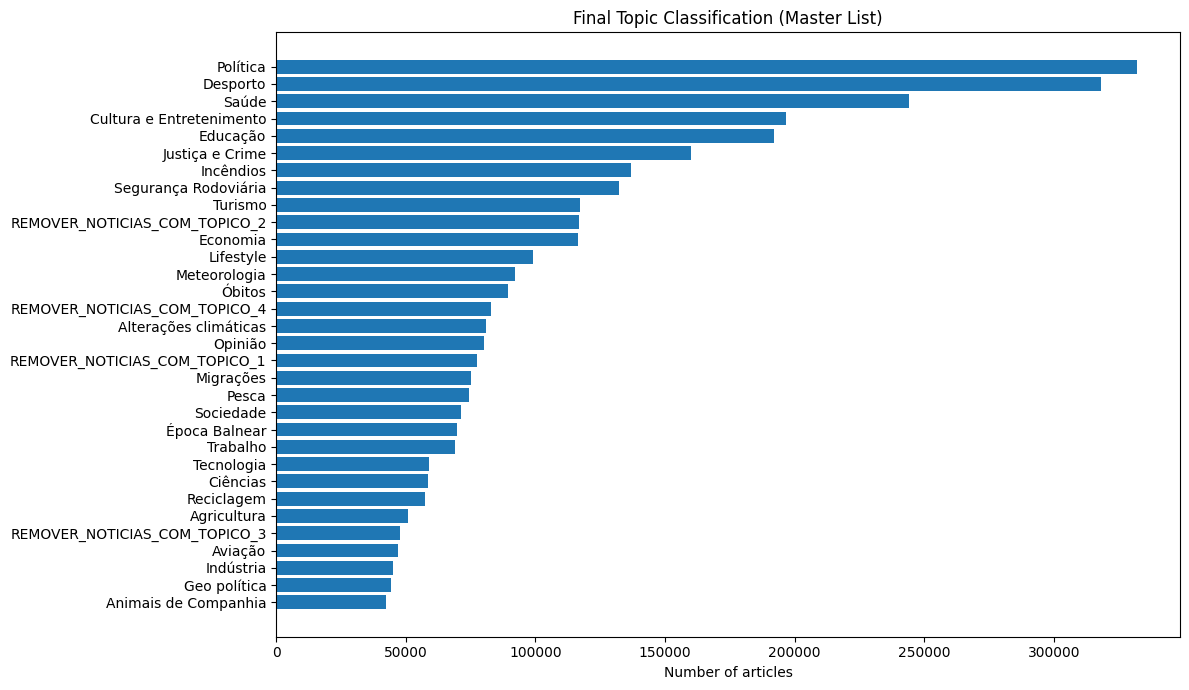

In [89]:
# Final topic distribution
topic_counts = articles.group_by("topic").len().sort("len", descending=True)
print("Final topic distribution:")
for row in topic_counts.iter_rows():
    print(f"  {row[0]:30s} {row[1]:>8,}")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    topic_counts["topic"].to_list()[::-1],
    topic_counts["len"].to_list()[::-1],
)
ax.set_xlabel("Number of articles")
ax.set_title("Final Topic Classification (Master List)")
plt.tight_layout()
plt.show()

In [99]:
TOPIC_SCORE_THRESHOLD = 0.03

Threshold: topic_score >= 0.03
Kept articles: 2,208,786 / 3,475,862 (63.5%)

Topic distribution (thresholded):
  Desporto                        240,052
  Política                        207,121
  Saúde                           192,642
  Educação                        130,764
  Justiça e Crime                 115,463
  Incêndios                        95,912
  Cultura e Entretenimento         85,230
  Segurança Rodoviária             82,317
  REMOVER_NOTICIAS_COM_TOPICO_2    68,043
  Turismo                          66,680
  Meteorologia                     64,956
  Economia                         62,117
  Lifestyle                        59,023
  Óbitos                           50,612
  REMOVER_NOTICIAS_COM_TOPICO_1    46,899
  Época Balnear                    46,680
  Alterações climáticas            44,405
  Trabalho                         43,379
  Reciclagem                       42,980
  Pesca                            42,922
  REMOVER_NOTICIAS_COM_TOPICO_4    41,744
  Migra

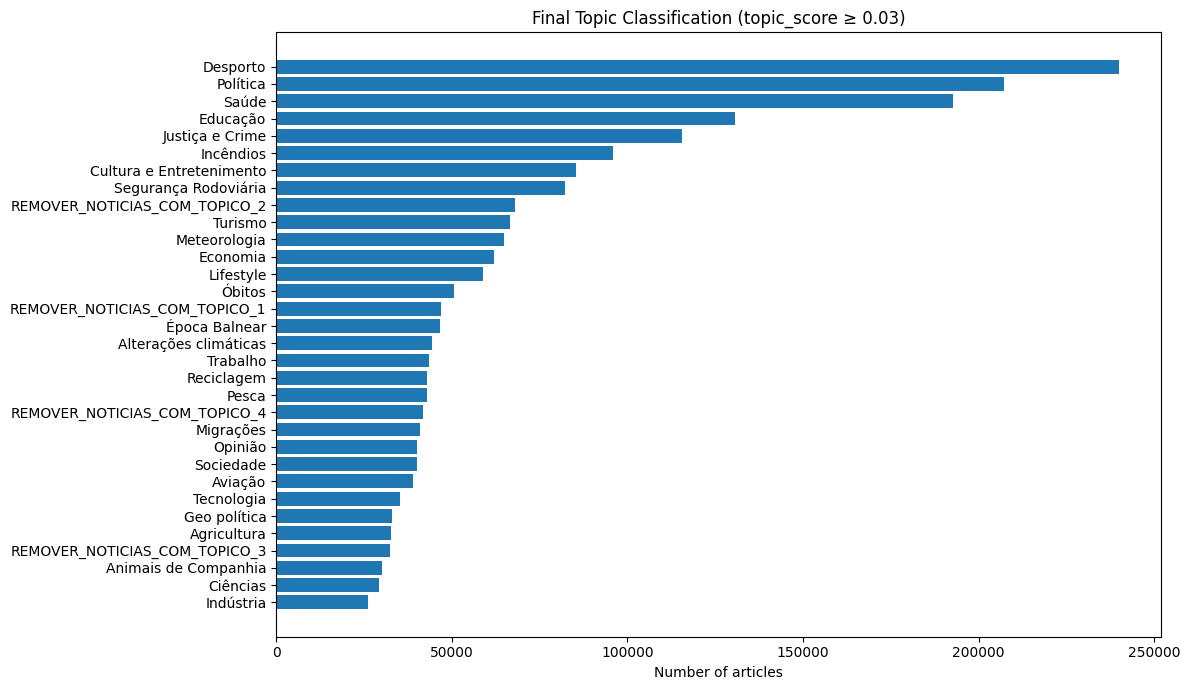

In [100]:
# Final topic distribution with a score threshold
threshold = TOPIC_SCORE_THRESHOLD if "TOPIC_SCORE_THRESHOLD" in globals() else 0.03

articles_thr = articles.filter(pl.col("topic_score") >= threshold)
topic_counts_thr = articles_thr.group_by("topic").len().sort("len", descending=True)

print(f"Threshold: topic_score >= {threshold}")
print(f"Kept articles: {len(articles_thr):,} / {len(articles):,} ({len(articles_thr)/len(articles)*100:.1f}%)")
print("\nTopic distribution (thresholded):")
for row in topic_counts_thr.iter_rows():
    print(f"  {row[0]:30s} {row[1]:>8,}")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    topic_counts_thr["topic"].to_list()[::-1],
    topic_counts_thr["len"].to_list()[::-1],
)
ax.set_xlabel("Number of articles")
ax.set_title(f"Final Topic Classification (topic_score ≥ {threshold})")
plt.tight_layout()
plt.show()

  Batch 0–100,000 done
  Batch 100,000–200,000 done
  Batch 200,000–300,000 done
  Batch 300,000–400,000 done
  Batch 400,000–500,000 done
  Batch 500,000–600,000 done
  Batch 600,000–700,000 done
  Batch 700,000–800,000 done
  Batch 800,000–900,000 done
  Batch 900,000–1,000,000 done
  Batch 1,000,000–1,100,000 done
  Batch 1,100,000–1,200,000 done
  Batch 1,200,000–1,300,000 done
  Batch 1,300,000–1,400,000 done
  Batch 1,400,000–1,500,000 done
  Batch 1,500,000–1,600,000 done
  Batch 1,600,000–1,700,000 done
  Batch 1,700,000–1,800,000 done
  Batch 1,800,000–1,900,000 done
  Batch 1,900,000–2,000,000 done
  Batch 2,000,000–2,100,000 done
  Batch 2,100,000–2,200,000 done
  Batch 2,200,000–2,300,000 done
  Batch 2,300,000–2,400,000 done
  Batch 2,400,000–2,500,000 done
  Batch 2,500,000–2,600,000 done
  Batch 2,600,000–2,700,000 done
  Batch 2,700,000–2,800,000 done
  Batch 2,800,000–2,900,000 done
  Batch 2,900,000–3,000,000 done
  Batch 3,000,000–3,100,000 done
  Batch 3,100,000–3,2

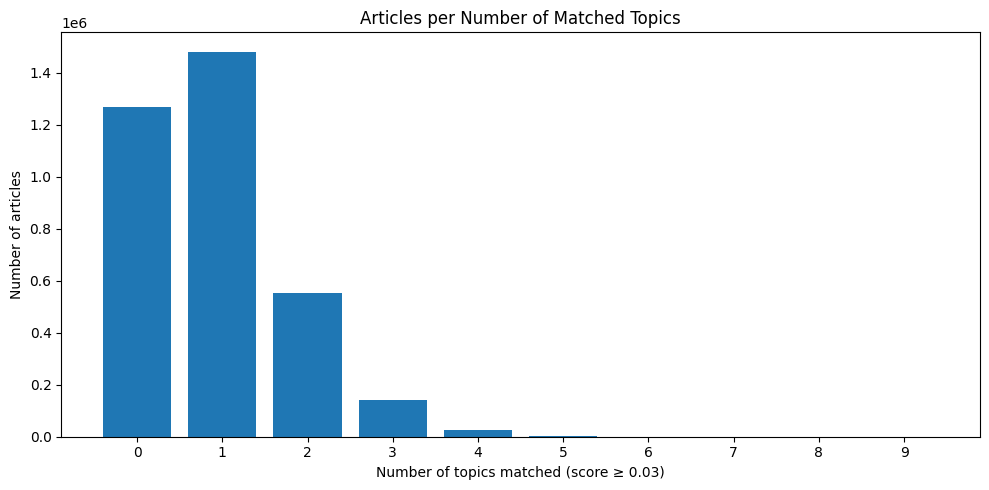

In [101]:
# Distribution: how many topics each article matches above a similarity threshold
BATCH_SIZE = 100_000

n_articles = tfidf_articles.shape[0]
n_topics = tfidf_master_topics.shape[0]

topic_match_hist = np.zeros(n_topics + 1, dtype=np.int64)  # index = number of matched topics

for start in range(0, n_articles, BATCH_SIZE):
	end = min(start + BATCH_SIZE, n_articles)
	sim_batch = cosine_similarity(tfidf_articles[start:end], tfidf_master_topics)  # (batch, n_topics)
	matches_per_article = (sim_batch >= TOPIC_SCORE_THRESHOLD).sum(axis=1).astype(np.int32)
	topic_match_hist += np.bincount(matches_per_article, minlength=n_topics + 1)
	print(f"  Batch {start:,}–{end:,} done")

# Build plotting vectors (only bins with at least 1 article)
x = np.arange(n_topics + 1)
mask = topic_match_hist > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x[mask], topic_match_hist[mask])
ax.set_xlabel(f"Number of topics matched (score ≥ {TOPIC_SCORE_THRESHOLD})")
ax.set_ylabel("Number of articles")
ax.set_title("Articles per Number of Matched Topics")
ax.set_xticks(x[mask])
plt.tight_layout()
plt.show()

## Step 5: Export Results

In [105]:
# Also save a CSV summary of topic counts per domain
domain_topic_counts = (
    articles.group_by(["domain", "topic"])
    .len()
    .sort(["domain", "len"], descending=[False, True])
)
domain_topic_counts.write_csv("domain_topic_counts.csv")
print(f"Saved domain × topic summary to domain_topic_counts.csv")

Saved domain × topic summary to domain_topic_counts.csv


In [106]:
# Save only {id, topic, topic_score} as JSON Lines (one JSON object per line)
json_output_path = Path("articles_topics.jsonl")

articles.select(["id", "topic", "topic_score"]).write_ndjson(json_output_path)

print(f"Saved JSONL to: {json_output_path}")
print(f"File size: {json_output_path.stat().st_size / 1024 / 1024:.1f} MB")

Saved JSONL to: articles_topics.jsonl
File size: 408.9 MB


NOTE:
- there are 4 topics that signal bad content: "REMOVER_NOTICIAS_COM_TOPICO_X". Any article classified under these should be removed from the final dataset, as they likely contain cookie banners, boilerplate text, or other non-news content.
- The final output is saved as `articles_topics.jsonl`, containing only the `id`, `topic`, and `topic_score` for each article. Apply a threshold when reading the topic_score, the above plot uses a sensible 0.03 based on the distribution of scores. a score of 0.05 is more conservative and results in fewer articles per topic, but also less noise. see below for the distribution of topic scores to choose threshold.

In [103]:
# Score distribution to help pick threshold
scores = articles["topic_score"].to_numpy()
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  P{p:2d}: {np.percentile(scores, p):.4f}")
print(f"  Mean: {scores.mean():.4f}")
print(f"  Std:  {scores.std():.4f}")
print()
# Count by threshold
for t in [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.10]:
    n = (scores >= t).sum()
    print(f"  ≥{t:.2f}: {n:>10,} ({n/len(scores)*100:.1f}%)")

  P 5: 0.0112
  P10: 0.0153
  P25: 0.0238
  P50: 0.0385
  P75: 0.0631
  P90: 0.1002
  P95: 0.1400
  Mean: 0.0537
  Std:  0.0578

  ≥0.01:  3,337,669 (96.0%)
  ≥0.02:  2,855,815 (82.2%)
  ≥0.03:  2,208,786 (63.5%)
  ≥0.04:  1,669,010 (48.0%)
  ≥0.05:  1,253,968 (36.1%)
  ≥0.07:    722,011 (20.8%)
  ≥0.10:    349,080 (10.0%)
